# NB-02 · SimCLR + DeepLabV3 for Brain Tumour Semantic Segmentation
## AMP-Stable Kaggle Revision: Contrastive Pretraining and Dense Mask Prediction

**Course:** CSE 438 · Digital Image Processing  
**Course Instructor:** Dr Md Rifat Ahmmad Rashid  
**Department:** Dept of CSE  
**Institution:** East West University (EWU)

---

### Notebook purpose

This notebook demonstrates a two-stage semantic-segmentation workflow for brain tumour MRI images:

\[
\text{MRI Images}
\xrightarrow{\text{SimCLR pretraining}}
\text{ResNet-50 encoder}
\xrightarrow{\text{transfer}}
\text{DeepLabV3}
\xrightarrow{\text{fine-tuning}}
\text{Binary tumour mask}
\]

The COCO polygons are merged into semantic masks using two labels: `0` for background and `1` for tumour region. SimCLR receives only images; masks are introduced during downstream segmentation fine-tuning and evaluation.

### Correction included in this revision

A previous execution failed during Stage A because AMP created `float16` contrastive logits and the NT-Xent mask attempted to insert `-1e9`, which cannot be represented in half precision. In this revision:

- the encoder forward pass may still use AMP after a successful CUDA kernel probe;
- the NT-Xent similarity matrix, masking operation, and cross-entropy calculation are explicitly computed in `float32`;
- tensors remain in the standard contiguous memory format; no executable `channels_last` conversion is used;
- if the assigned Kaggle GPU cannot execute a basic convolution kernel, the notebook switches to CPU and prints the diagnostic reason.

### Training plan

| Stage | Network | Objective | Epochs |
|---|---|---|---:|
| A | ResNet-50 encoder + SimCLR projection head | NT-Xent loss | 10 |
| B | DeepLabV3-ResNet50 | Cross-entropy + foreground Dice loss | 10 |

The ten-epoch setting is intended for classroom interpretation of the method rather than clinical validation.

## 0. Dataset and notebook outputs

Use the supplied Kaggle dataset without changing the root path:

```python
from pathlib import Path
DATA_ROOT = Path("/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation")
```

Expected split structure:

```text
DATA_ROOT/
├── train/
│   ├── _annotations.coco.json
│   └── image files
├── valid/
│   ├── _annotations.coco.json
│   └── image files
└── test/
    ├── _annotations.coco.json
    └── image files
```

All model checkpoints, metrics and generated figures are written under:

```text
/kaggle/working/simclr_deeplabv3_outputs/
```

In [1]:
# ============================================================
# Cell 1: Imports, configuration, reproducibility and device safety
# ============================================================
import copy
import gc
import json
import os
import random
import warnings
from collections import defaultdict
from contextlib import nullcontext
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50
from torchvision.models.segmentation import deeplabv3_resnet50

from sklearn.manifold import TSNE

warnings.filterwarnings("ignore", category=UserWarning)


@dataclass
class CFG:
    # Reproducibility and image dimensions
    seed: int = 42
    image_size: int = 224
    num_workers: int = 0 #min(4, os.cpu_count() or 2)

    # Stage A: SimCLR pretraining
    ssl_epochs: int = 10
    ssl_batch_size: int = 32
    ssl_learning_rate: float = 3e-4
    temperature: float = 0.20
    projection_hidden_dim: int = 512
    projection_dim: int = 128

    # Stage B: semantic segmentation fine-tuning
    seg_epochs: int = 10
    seg_batch_size: int = 8
    seg_learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    number_of_classes: int = 2  # 0 = background, 1 = tumour

    # Visual analysis
    number_of_qualitative_samples: int = 4
    tsne_max_samples: int = 600

    # Runtime controls
    use_amp: bool = True
    force_cpu: bool = False
    debug_subset: Optional[int] = None  # Set, for example, to 128 for a short code check.


cfg = CFG()

# Exact Kaggle location required for this classroom experiment.
DATA_ROOT = Path("/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation")
OUTPUT_DIR = Path("/kaggle/working/simclr_deeplabv3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_PATHS = {
    "train": (DATA_ROOT / "train", DATA_ROOT / "train" / "_annotations.coco.json"),
    "valid": (DATA_ROOT / "valid", DATA_ROOT / "valid" / "_annotations.coco.json"),
    "test": (DATA_ROOT / "test", DATA_ROOT / "test" / "_annotations.coco.json"),
}


def seed_everything(seed: int) -> None:
    """Fix random states so classroom runs are easier to compare."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def select_safe_device() -> tuple[torch.device, bool]:
    """Use CUDA only after executing a standard contiguous convolution kernel.

    Some Kaggle sessions expose a CUDA device even when the installed PyTorch build
    cannot execute kernels on that device. The check is deliberately performed
    before training, and no channels-last conversion is attempted.
    """
    if cfg.force_cpu:
        print("CPU execution was requested through cfg.force_cpu.")
        return torch.device("cpu"), False

    if not torch.cuda.is_available():
        print("CUDA is not available. Training will proceed on CPU.")
        return torch.device("cpu"), False

    try:
        candidate = torch.device("cuda")
        probe_x = torch.randn(2, 3, 32, 32, device=candidate).contiguous()
        probe_layer = nn.Conv2d(3, 8, kernel_size=3, padding=1).to(candidate)
        probe_output = probe_layer(probe_x)
        probe_loss = probe_output.float().mean()
        probe_loss.backward()
        torch.cuda.synchronize()
        print(
            "CUDA kernel probe passed: "
            f"{torch.cuda.get_device_name(0)} | "
            f"compute capability {torch.cuda.get_device_capability(0)}"
        )
        return candidate, True
    except Exception as error:
        print("CUDA is visible but a standard convolution kernel could not be executed.")
        print(f"Diagnostic message: {type(error).__name__}: {str(error).splitlines()[0]}")
        print("Continuing on CPU with AMP disabled. No package installation is required.")
        gc.collect()
        return torch.device("cpu"), False


def amp_context():
    """Return autocast only when a CUDA kernel has already been verified."""
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=torch.float16, enabled=True)
    return nullcontext()


seed_everything(cfg.seed)
device, CUDA_FUNCTIONAL = select_safe_device()
AMP_ENABLED = bool(cfg.use_amp and CUDA_FUNCTIONAL and device.type == "cuda")
SCALER = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

print("\nRuntime configuration")
display(pd.Series(asdict(cfg)).to_frame("value"))
print("PyTorch version:", torch.__version__)
print("Selected device:", device)
print("AMP enabled:", AMP_ENABLED)
print("Output directory:", OUTPUT_DIR)

CUDA kernel probe passed: Tesla T4 | compute capability (7, 5)

Runtime configuration


,value
seed,42
image_size,224
num_workers,0
ssl_epochs,10
ssl_batch_size,32
ssl_learning_rate,0.0003
temperature,0.2
projection_hidden_dim,512
projection_dim,128
seg_epochs,10


PyTorch version: 2.10.0+cu128
Selected device: cuda
AMP enabled: True
Output directory: /kaggle/working/simclr_deeplabv3_outputs


## 1. COCO polygon conversion into binary semantic masks

The annotation file may contain more than one polygon for an image. Semantic segmentation does not retain instance identity; consequently, all tumour polygons from the same image are combined into a single foreground map:

\[
M(x,y)=
\begin{cases}
1, & \text{when at least one tumour polygon covers pixel } (x,y),\\
0, & \text{otherwise.}
\end{cases}
\]

The following code uses polygon rasterisation and produces binary masks only. It therefore matches the stated COCO polygon format of the dataset.

In [2]:
# ============================================================
# Cell 2: COCO reading utilities and image-level split indices
# ============================================================
def verify_dataset_paths() -> None:
    """Check that the dataset has been attached to the Kaggle notebook."""
    missing = []
    for image_directory, annotation_file in SPLIT_PATHS.values():
        if not image_directory.exists():
            missing.append(str(image_directory))
        if not annotation_file.exists():
            missing.append(str(annotation_file))
    if missing:
        raise FileNotFoundError(
            "The required Kaggle dataset files were not found. Attach the dataset "
            "and retain the supplied DATA_ROOT path. Missing paths:\n- "
            + "\n- ".join(missing)
        )


def locate_image(image_directory: Path, file_name: str) -> Path:
    """Resolve either a direct image filename or a nested COCO relative path."""
    direct_path = image_directory / file_name
    basename_path = image_directory / Path(file_name).name
    if direct_path.exists():
        return direct_path
    return basename_path


def polygon_annotations_to_binary_mask(
    annotations: list[dict], height: int, width: int
) -> np.ndarray:
    """Merge all COCO polygon segments for one MRI image into one binary mask."""
    canvas = Image.new("L", (width, height), 0)
    drawing_context = ImageDraw.Draw(canvas)

    for annotation in annotations:
        segmentation = annotation.get("segmentation", [])
        if not isinstance(segmentation, list):
            raise TypeError(
                "An RLE annotation was found, but this notebook is specified for COCO polygons."
            )
        for polygon in segmentation:
            if len(polygon) < 6:
                continue
            points = [
                (float(polygon[index]), float(polygon[index + 1]))
                for index in range(0, len(polygon) - 1, 2)
            ]
            drawing_context.polygon(points, fill=1, outline=1)

    return np.asarray(canvas, dtype=np.uint8)


def build_split_index(split_name: str) -> pd.DataFrame:
    """Construct an image-level index and retain its polygon annotations."""
    image_directory, annotation_file = SPLIT_PATHS[split_name]
    with open(annotation_file, "r", encoding="utf-8") as file_handle:
        coco = json.load(file_handle)

    annotations_by_image = defaultdict(list)
    for annotation in coco.get("annotations", []):
        annotations_by_image[annotation["image_id"]].append(annotation)

    rows = []
    for image_info in coco.get("images", []):
        image_id = image_info["id"]
        height, width = int(image_info["height"]), int(image_info["width"])
        annotations = annotations_by_image.get(image_id, [])
        image_path = locate_image(image_directory, image_info["file_name"])
        if not image_path.exists():
            raise FileNotFoundError(f"Image referenced by COCO JSON was not found: {image_path}")

        # Construct the precise merged semantic mask once for area statistics.
        binary_mask = polygon_annotations_to_binary_mask(annotations, height, width)
        mask_ratio = float(binary_mask.mean())
        rows.append(
            {
                "split": split_name,
                "image_id": image_id,
                "path": str(image_path),
                "height": height,
                "width": width,
                "annotations": annotations,
                "instances": len(annotations),
                "mask_ratio": mask_ratio,
            }
        )

    frame = pd.DataFrame(rows)
    if frame.empty:
        raise ValueError(f"No images were indexed for split: {split_name}")
    return frame


def assign_area_groups(frames: dict[str, pd.DataFrame]) -> dict[int, str]:
    """Create interpretation groups for t-SNE colouring; these are never training labels."""
    train_ratios = frames["train"]["mask_ratio"].to_numpy()
    positive_ratios = train_ratios[train_ratios > 0]
    if len(positive_ratios) >= 3 and np.unique(positive_ratios).size >= 3:
        first_edge, second_edge = np.quantile(positive_ratios, [1 / 3, 2 / 3])
        for frame in frames.values():
            frame["feature_group"] = np.select(
                [frame["mask_ratio"] <= 0, frame["mask_ratio"] <= first_edge,
                 frame["mask_ratio"] <= second_edge],
                [0, 1, 2],
                default=3,
            ).astype(int)
        return {0: "No foreground", 1: "Small tumour area", 2: "Medium tumour area", 3: "Large tumour area"}

    for frame in frames.values():
        frame["feature_group"] = (frame["mask_ratio"] > 0).astype(int)
    return {0: "No foreground", 1: "Tumour foreground present"}


verify_dataset_paths()
split_frames = {split_name: build_split_index(split_name) for split_name in SPLIT_PATHS}

if cfg.debug_subset is not None:
    split_frames["train"] = split_frames["train"].sample(
        min(cfg.debug_subset, len(split_frames["train"])), random_state=cfg.seed
    ).reset_index(drop=True)

feature_group_names = assign_area_groups(split_frames)
summary_table = pd.DataFrame(
    {
        split_name: {
            "Images": len(frame),
            "Images with tumour mask": int((frame["mask_ratio"] > 0).sum()),
            "Mean foreground ratio": frame["mask_ratio"].mean(),
            "Maximum foreground ratio": frame["mask_ratio"].max(),
        }
        for split_name, frame in split_frames.items()
    }
).T

print("Dataset root:", DATA_ROOT)
display(summary_table.round(4))
print("t-SNE colouring groups:", feature_group_names)

Dataset root: /kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation


,Images,Images with tumour mask,Mean foreground ratio,Maximum foreground ratio
train,1502.0,1501.0,0.0371,0.3154
valid,429.0,429.0,0.0372,0.1631
test,215.0,215.0,0.0371,0.1748


t-SNE colouring groups: {0: 'No foreground', 1: 'Small tumour area', 2: 'Medium tumour area', 3: 'Large tumour area'}


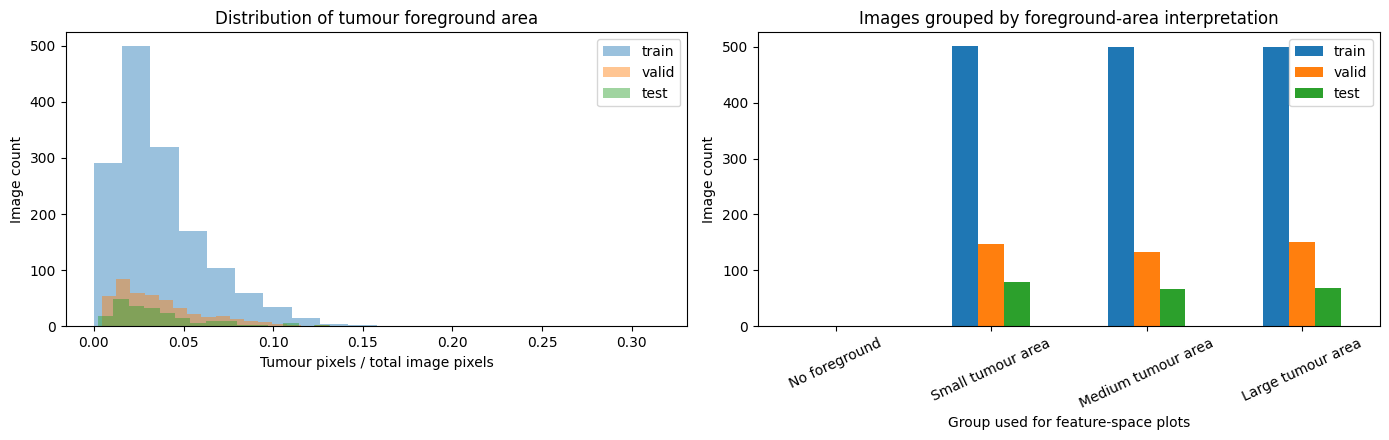

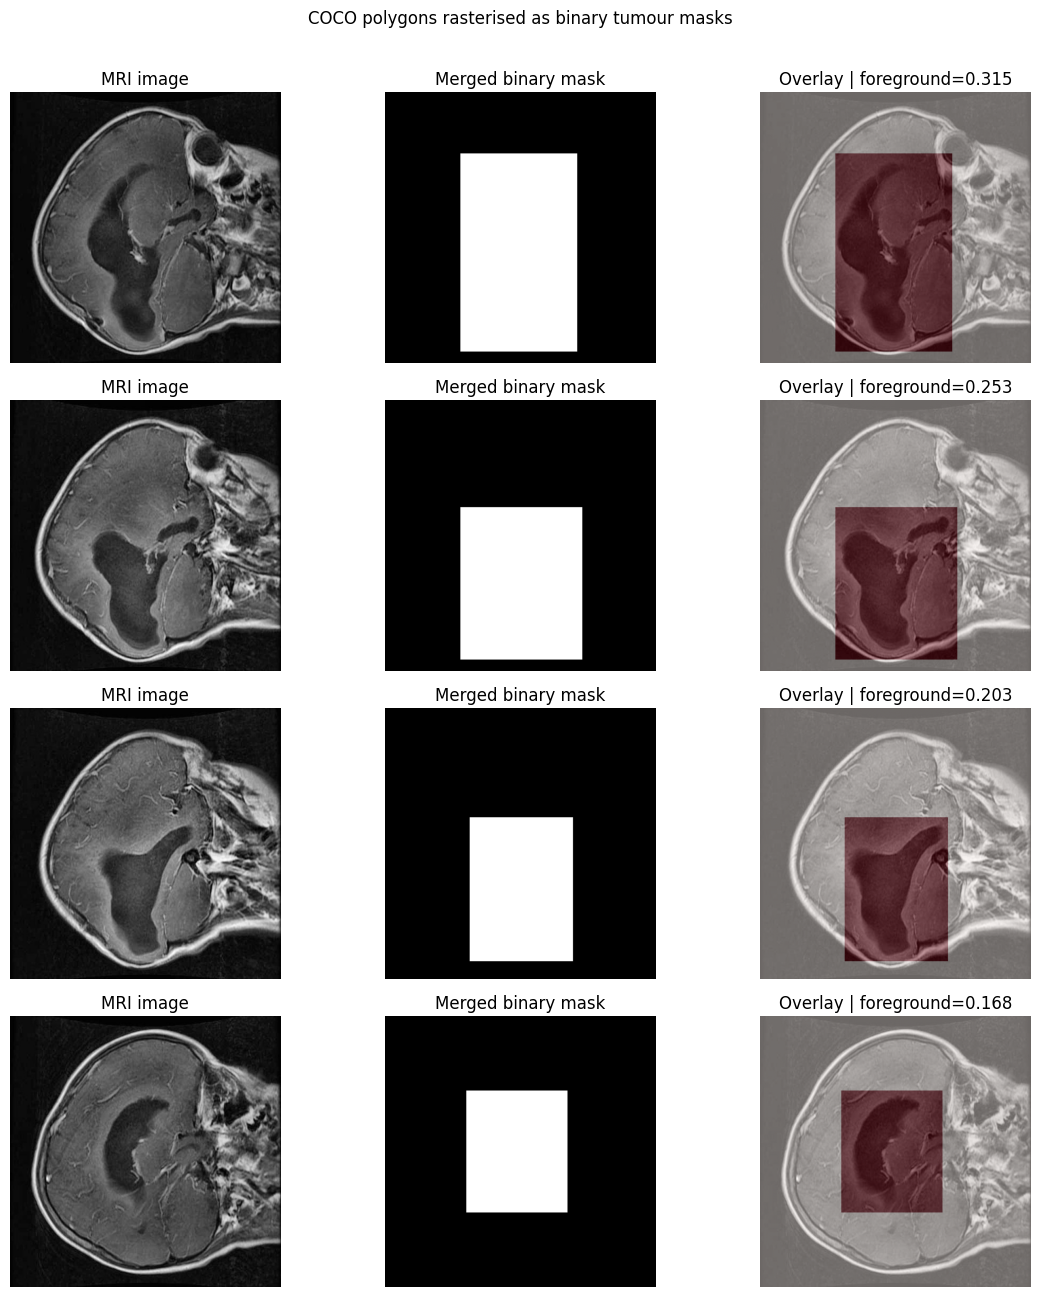

In [3]:
# ============================================================
# Cell 3: Annotation distribution and mask-overlay visual inspection
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for split_name, frame in split_frames.items():
    axes[0].hist(frame["mask_ratio"], bins=20, alpha=0.45, label=split_name)
axes[0].set_title("Distribution of tumour foreground area")
axes[0].set_xlabel("Tumour pixels / total image pixels")
axes[0].set_ylabel("Image count")
axes[0].legend()

area_counts = pd.DataFrame(
    {split_name: frame["feature_group"].value_counts().sort_index()
     for split_name, frame in split_frames.items()}
).fillna(0)
area_counts.index = [feature_group_names.get(int(value), str(value)) for value in area_counts.index]
area_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("Images grouped by foreground-area interpretation")
axes[1].set_xlabel("Group used for feature-space plots")
axes[1].set_ylabel("Image count")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


def load_raw_image_and_mask(row: pd.Series) -> tuple[Image.Image, np.ndarray]:
    image = Image.open(row["path"]).convert("RGB")
    mask = polygon_annotations_to_binary_mask(row["annotations"], row["height"], row["width"])
    return image, mask


examples = split_frames["train"].sort_values("mask_ratio", ascending=False).head(4)
fig, axes = plt.subplots(len(examples), 3, figsize=(12, 3.2 * len(examples)))
for plot_row, (_, sample) in enumerate(examples.iterrows()):
    image, mask = load_raw_image_and_mask(sample)
    axes[plot_row, 0].imshow(image)
    axes[plot_row, 0].set_title("MRI image")
    axes[plot_row, 1].imshow(mask, cmap="gray", vmin=0, vmax=1)
    axes[plot_row, 1].set_title("Merged binary mask")
    axes[plot_row, 2].imshow(image)
    axes[plot_row, 2].imshow(mask, cmap="Reds", alpha=0.42, vmin=0, vmax=1)
    axes[plot_row, 2].set_title(f"Overlay | foreground={sample['mask_ratio']:.3f}")
    for column in range(3):
        axes[plot_row, column].axis("off")
plt.suptitle("COCO polygons rasterised as binary tumour masks", y=1.01)
plt.tight_layout()
plt.show()

## 2. Stage A — SimCLR representation learning

For each unlabelled MRI image, two independently transformed views form a positive pair. The projection head maps encoder features to a contrastive space, while other images in the mini-batch provide negative examples.

\[
\ell_{i,j}=-\log\frac{\exp(\operatorname{sim}(z_i,z_j)/\tau)}
{\sum_{k\neq i}\exp(\operatorname{sim}(z_i,z_k)/\tau)}
\]

The temperature parameter \(\tau\) regulates the concentration of similarity scores. The segmentation annotations remain unused at this stage. Colour jitter is limited because the underlying medical images are effectively grayscale and anatomical structure must be retained.

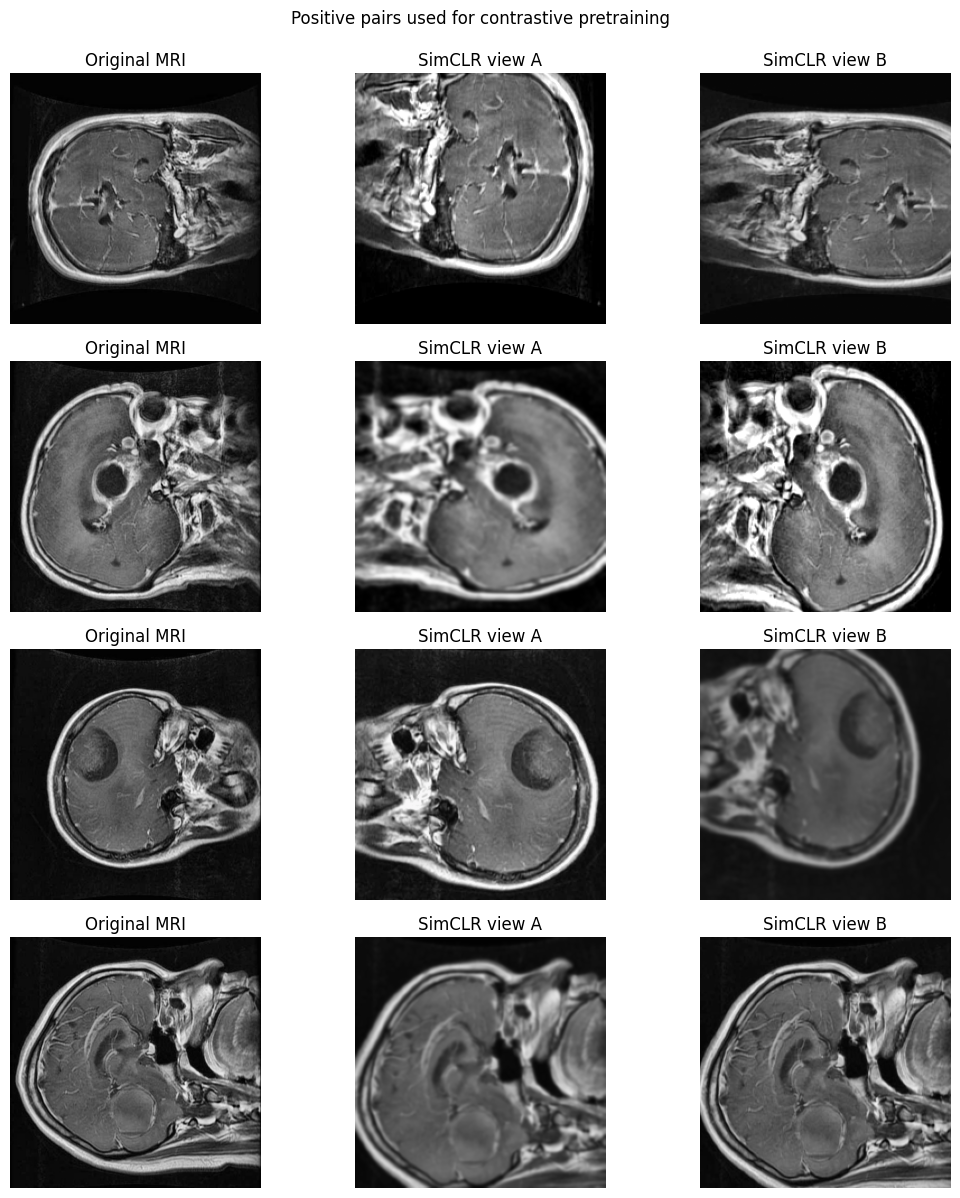

In [4]:
# ============================================================
# Cell 4: SimCLR views and supervised segmentation datasets
# ============================================================
NORMALISATION_MEAN = (0.485, 0.456, 0.406)
NORMALISATION_STD = (0.229, 0.224, 0.225)

simclr_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(cfg.image_size, scale=(0.70, 1.00), antialias=True),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.25, contrast=0.25)], p=0.60),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=15, sigma=(0.1, 1.5))], p=0.30),
        transforms.ToTensor(),
        transforms.Normalize(NORMALISATION_MEAN, NORMALISATION_STD),
    ]
)

image_transform = transforms.Compose(
    [
        transforms.Resize((cfg.image_size, cfg.image_size), antialias=True),
        transforms.ToTensor(),
        transforms.Normalize(NORMALISATION_MEAN, NORMALISATION_STD),
    ]
)


def denormalise_image(tensor: torch.Tensor) -> torch.Tensor:
    """Convert a normalised tensor to a displayable [0, 1] image."""
    mean = torch.tensor(NORMALISATION_MEAN).view(3, 1, 1)
    std = torch.tensor(NORMALISATION_STD).view(3, 1, 1)
    return (tensor.detach().cpu() * std + mean).clamp(0, 1)


class SimCLRDataset(Dataset):
    """Return two independent augmentations of one image without using masks."""
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        image = Image.open(self.frame.loc[index, "path"]).convert("RGB")
        return simclr_transform(image), simclr_transform(image)


class SemanticSegmentationDataset(Dataset):
    """Return a resized MRI tensor, merged binary tumour mask and metadata."""
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.loc[index]
        image = Image.open(row["path"]).convert("RGB")
        mask = polygon_annotations_to_binary_mask(row["annotations"], row["height"], row["width"])
        mask_image = Image.fromarray((mask * 255).astype(np.uint8)).resize(
            (cfg.image_size, cfg.image_size), resample=Image.Resampling.NEAREST
        )
        mask_tensor = torch.from_numpy((np.asarray(mask_image) > 0).astype(np.int64))
        return image_transform(image), mask_tensor, int(row["feature_group"]), str(row["path"])


class FeatureDataset(Dataset):
    """Return consistently resized images and area-group identifiers for t-SNE."""
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.loc[index]
        image = Image.open(row["path"]).convert("RGB")
        return image_transform(image), int(row["feature_group"])


simclr_train_dataset = SimCLRDataset(split_frames["train"])
simclr_valid_dataset = SimCLRDataset(split_frames["valid"])
segmentation_train_dataset = SemanticSegmentationDataset(split_frames["train"])
segmentation_valid_dataset = SemanticSegmentationDataset(split_frames["valid"])
segmentation_test_dataset = SemanticSegmentationDataset(split_frames["test"])

# SimCLR requires negative samples. drop_last=True prevents a one-image terminal batch.
simclr_train_loader = DataLoader(
    simclr_train_dataset, batch_size=cfg.ssl_batch_size, shuffle=True,
    num_workers=cfg.num_workers, pin_memory=(device.type == "cuda"), drop_last=True
)
simclr_valid_loader = DataLoader(
    simclr_valid_dataset, batch_size=cfg.ssl_batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=(device.type == "cuda"), drop_last=False
)
segmentation_train_loader = DataLoader(
    segmentation_train_dataset, batch_size=cfg.seg_batch_size, shuffle=True,
    num_workers=cfg.num_workers, pin_memory=(device.type == "cuda"), drop_last=False
)
segmentation_valid_loader = DataLoader(
    segmentation_valid_dataset, batch_size=cfg.seg_batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=(device.type == "cuda"), drop_last=False
)
segmentation_test_loader = DataLoader(
    segmentation_test_dataset, batch_size=cfg.seg_batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=(device.type == "cuda"), drop_last=False
)

# Students should first confirm that the two views preserve anatomical identity.
fig, axes = plt.subplots(4, 3, figsize=(11, 12))
for row_index in range(min(4, len(simclr_train_dataset))):
    original = Image.open(split_frames["train"].iloc[row_index]["path"]).convert("RGB")
    first_view, second_view = simclr_train_dataset[row_index]
    axes[row_index, 0].imshow(original)
    axes[row_index, 0].set_title("Original MRI")
    axes[row_index, 1].imshow(denormalise_image(first_view).permute(1, 2, 0))
    axes[row_index, 1].set_title("SimCLR view A")
    axes[row_index, 2].imshow(denormalise_image(second_view).permute(1, 2, 0))
    axes[row_index, 2].set_title("SimCLR view B")
    for column in range(3):
        axes[row_index, column].axis("off")
plt.suptitle("Positive pairs used for contrastive pretraining", y=0.995)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Cell 6: ResNet-50 SimCLR model and AMP-stable NT-Xent objective
# ============================================================
class SimCLRModel(nn.Module):
    """ResNet-50 encoder with an MLP projection head for contrastive learning."""
    def __init__(self):
        super().__init__()
        self.encoder = resnet50(weights=None)
        feature_dimension = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()
        self.projector = nn.Sequential(
            nn.Linear(feature_dimension, cfg.projection_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(cfg.projection_hidden_dim, cfg.projection_dim),
        )

    def forward(self, images: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        features = self.encoder(images)
        projections = self.projector(features)
        return features, projections


def nt_xent_loss(
    first_projection: torch.Tensor,
    second_projection: torch.Tensor,
    temperature: float,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Compute SimCLR NT-Xent loss in float32 for stability under AMP.

    The model forward pass may occur in float16 when AMP is active. Similarity
    logits and their masked diagonal are more numerically sensitive: replacing a
    diagonal logit with -1e9 overflows in float16. Casting the projection vectors
    to float32 before forming logits prevents that failure while leaving the
    high-cost encoder computation eligible for AMP acceleration.
    """
    if first_projection.shape != second_projection.shape or first_projection.ndim != 2:
        raise ValueError("Both projection tensors must share shape [batch_size, projection_dimension].")
    batch_size = first_projection.size(0)
    if batch_size < 2:
        raise ValueError("NT-Xent requires at least two images per mini-batch.")

    # Explicitly disable autocast for this objective even if it is called from an autocast block.
    with torch.autocast(device_type=first_projection.device.type, enabled=False):
        first_projection = F.normalize(first_projection.float(), dim=1)
        second_projection = F.normalize(second_projection.float(), dim=1)
        representations = torch.cat([first_projection, second_projection], dim=0)
        total_samples = representations.size(0)

        cosine_similarity = representations @ representations.T
        logits = cosine_similarity / float(temperature)

        self_mask = torch.eye(total_samples, device=logits.device, dtype=torch.bool)
        # logits are float32; using the datatype minimum excludes self-comparisons safely.
        logits = logits.masked_fill(self_mask, torch.finfo(logits.dtype).min)

        sample_indices = torch.arange(total_samples, device=logits.device)
        positive_indices = (sample_indices + batch_size) % total_samples
        loss = F.cross_entropy(logits, positive_indices)

        positive_similarity = cosine_similarity[sample_indices, positive_indices].mean().detach()
        positive_mask = torch.zeros_like(self_mask)
        positive_mask[sample_indices, positive_indices] = True
        negative_mask = ~(self_mask | positive_mask)
        negative_similarity = cosine_similarity[negative_mask].mean().detach()

    return loss, positive_similarity, negative_similarity


simclr_model = SimCLRModel().to(device)
initial_simclr_state = copy.deepcopy({key: value.detach().cpu() for key, value in simclr_model.state_dict().items()})
ssl_optimizer = torch.optim.AdamW(
    simclr_model.parameters(), lr=cfg.ssl_learning_rate, weight_decay=cfg.weight_decay
)
ssl_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ssl_optimizer, T_max=cfg.ssl_epochs)

print("SimCLR model created. Projection dimensionality:", cfg.projection_dim)

SimCLR model created. Projection dimensionality: 128


In [6]:
# ============================================================
# Cell 7: Numerical smoke test and 10-epoch SimCLR training
# ============================================================
def move_images_to_device(images: torch.Tensor) -> torch.Tensor:
    """Use conventional contiguous tensors; channels_last is deliberately excluded."""
    return images.to(device, non_blocking=(device.type == "cuda")).contiguous()


def run_simclr_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scaler: Optional[torch.amp.GradScaler] = None,
    description: str = "SimCLR",
) -> dict[str, float]:
    training = optimizer is not None
    model.train(training)
    losses, positive_values, negative_values = [], [], []

    progress_bar = tqdm(loader, desc=description, leave=False)
    for first_view, second_view in progress_bar:
        # Validation may retain a single terminal sample; it has no within-batch negatives.
        if first_view.size(0) < 2:
            continue

        first_view = move_images_to_device(first_view)
        second_view = move_images_to_device(second_view)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            # AMP is retained for the encoder and projection-head forward passes only.
            with amp_context():
                _, first_projection = model(first_view)
                _, second_projection = model(second_view)

            # This function deliberately calculates contrastive logits and CE in float32.
            loss, positive_similarity, negative_similarity = nt_xent_loss(
                first_projection, second_projection, cfg.temperature
            )

            if not torch.isfinite(loss):
                raise RuntimeError("A non-finite NT-Xent loss was detected; training was stopped.")

            if training:
                if AMP_ENABLED:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        losses.append(loss.item())
        positive_values.append(positive_similarity.item())
        negative_values.append(negative_similarity.item())
        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            positive=f"{positive_similarity.item():.3f}",
            negative=f"{negative_similarity.item():.3f}",
        )

    if not losses:
        raise ValueError("No valid SimCLR mini-batches were processed. Reduce batch size only if necessary.")
    return {
        "loss": float(np.mean(losses)),
        "positive_similarity": float(np.mean(positive_values)),
        "negative_similarity": float(np.mean(negative_values)),
    }


# A single forward pass confirms that AMP and float32 NT-Xent coexist safely before training.
first_check, second_check = next(iter(simclr_train_loader))
first_check = move_images_to_device(first_check[: min(4, first_check.size(0))])
second_check = move_images_to_device(second_check[: min(4, second_check.size(0))])
simclr_model.train()
with torch.no_grad():
    with amp_context():
        _, first_check_projection = simclr_model(first_check)
        _, second_check_projection = simclr_model(second_check)
    smoke_loss, smoke_positive, smoke_negative = nt_xent_loss(
        first_check_projection, second_check_projection, cfg.temperature
    )
assert torch.isfinite(smoke_loss), "SimCLR smoke test produced a non-finite loss."
print(
    f"AMP-stable NT-Xent smoke test passed | loss={smoke_loss.item():.4f} | "
    f"positive={smoke_positive.item():.3f} | negative={smoke_negative.item():.3f}"
)

ssl_records = []
best_ssl_loss = float("inf")
best_ssl_state = None

for epoch in tqdm(range(1, cfg.ssl_epochs + 1), desc="Stage A: SimCLR epochs"):
    training_results = run_simclr_epoch(
        simclr_model, simclr_train_loader, ssl_optimizer, SCALER,
        description=f"SimCLR train {epoch}/{cfg.ssl_epochs}"
    )
    with torch.inference_mode():
        validation_results = run_simclr_epoch(
            simclr_model, simclr_valid_loader,
            description=f"SimCLR valid {epoch}/{cfg.ssl_epochs}"
        )

    ssl_scheduler.step()
    ssl_records.append(
        {
            "epoch": epoch,
            "train_loss": training_results["loss"],
            "valid_loss": validation_results["loss"],
            "train_positive_similarity": training_results["positive_similarity"],
            "valid_positive_similarity": validation_results["positive_similarity"],
            "train_negative_similarity": training_results["negative_similarity"],
            "valid_negative_similarity": validation_results["negative_similarity"],
            "learning_rate": ssl_optimizer.param_groups[0]["lr"],
        }
    )
    if validation_results["loss"] < best_ssl_loss:
        best_ssl_loss = validation_results["loss"]
        best_ssl_state = copy.deepcopy({key: value.detach().cpu() for key, value in simclr_model.state_dict().items()})

simclr_model.load_state_dict(best_ssl_state)
simclr_model.to(device)
ssl_history = pd.DataFrame(ssl_records)
ssl_checkpoint = OUTPUT_DIR / "simclr_resnet50_encoder_projection_head_amp_stable.pt"
ssl_history_file = OUTPUT_DIR / "simclr_training_history.csv"
torch.save(simclr_model.state_dict(), ssl_checkpoint)
ssl_history.to_csv(ssl_history_file, index=False)

print(f"Best validation NT-Xent loss: {best_ssl_loss:.4f}")
display(ssl_history.round(4))
print("Saved:", ssl_checkpoint)

AMP-stable NT-Xent smoke test passed | loss=1.9231 | positive=0.965 | negative=0.958


Stage A: SimCLR epochs:   0%|          | 0/10 [00:00<?, ?it/s]

SimCLR train 1/10:   0%|          | 0/46 [00:00<?, ?it/s]

SimCLR valid 1/10:   0%|          | 0/14 [00:00<?, ?it/s]

SimCLR train 2/10:   0%|          | 0/46 [00:00<?, ?it/s]

...

SimCLR train 10/10:   0%|          | 0/46 [00:00<?, ?it/s]

SimCLR valid 10/10:   0%|          | 0/14 [00:00<?, ?it/s]

Best validation NT-Xent loss: 1.5239


,epoch,train_loss,valid_loss,train_positive_similarity,valid_positive_similarity,train_negative_similarity,valid_negative_similarity,learning_rate
0,1,3.8142,3.4241,0.9508,0.9386,0.7487,0.5275,0.0003
1,2,3.3055,3.1778,0.9275,0.9239,0.3954,0.2910,0.0003
2,3,3.1475,3.0213,0.9027,0.8991,0.2391,0.3411,0.0002
3,4,2.7056,2.4923,0.8823,0.8867,0.0958,0.0864,0.0002
4,5,2.3425,2.3008,0.8924,0.8766,0.0283,0.1001,0.0001
5,6,2.0046,2.0007,0.8909,0.8852,0.0065,0.0295,0.0001
6,7,1.8624,1.8026,0.8957,0.8965,0.0033,0.0183,0.0001
7,8,1.6832,1.6189,0.9097,0.9194,-0.0127,0.0171,0.0000
8,9,1.5923,1.5410,0.9129,0.9136,-0.0164,0.0043,0.0000
9,10,1.5699,1.5239,0.9117,0.9193,-0.0163,-0.0007,0.0000


Saved: /kaggle/working/simclr_deeplabv3_outputs/simclr_resnet50_encoder_projection_head_amp_stable.pt


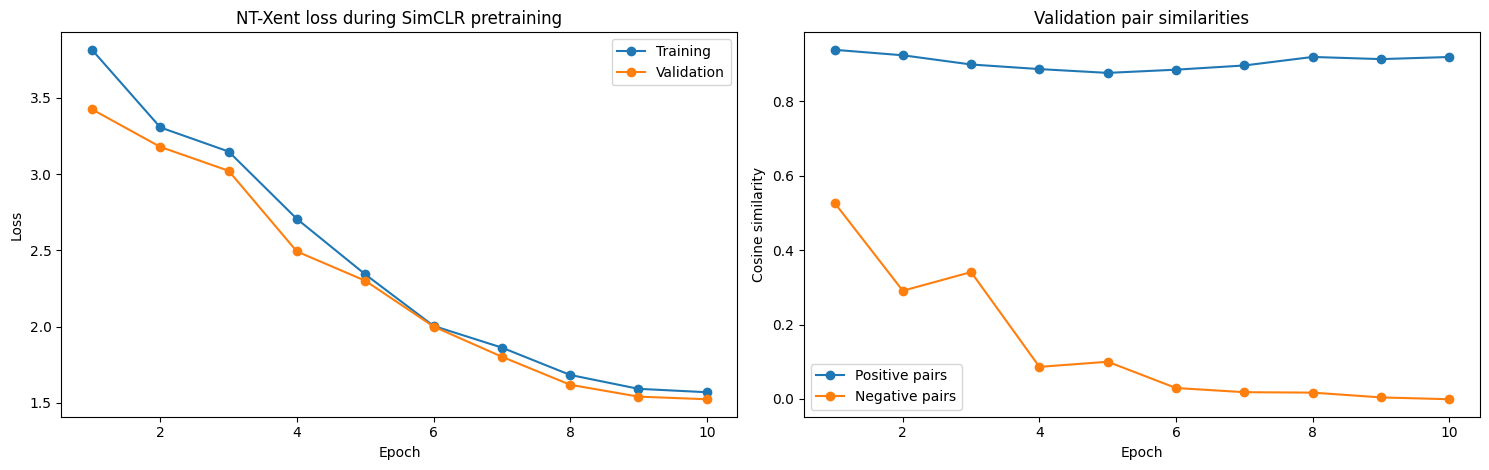

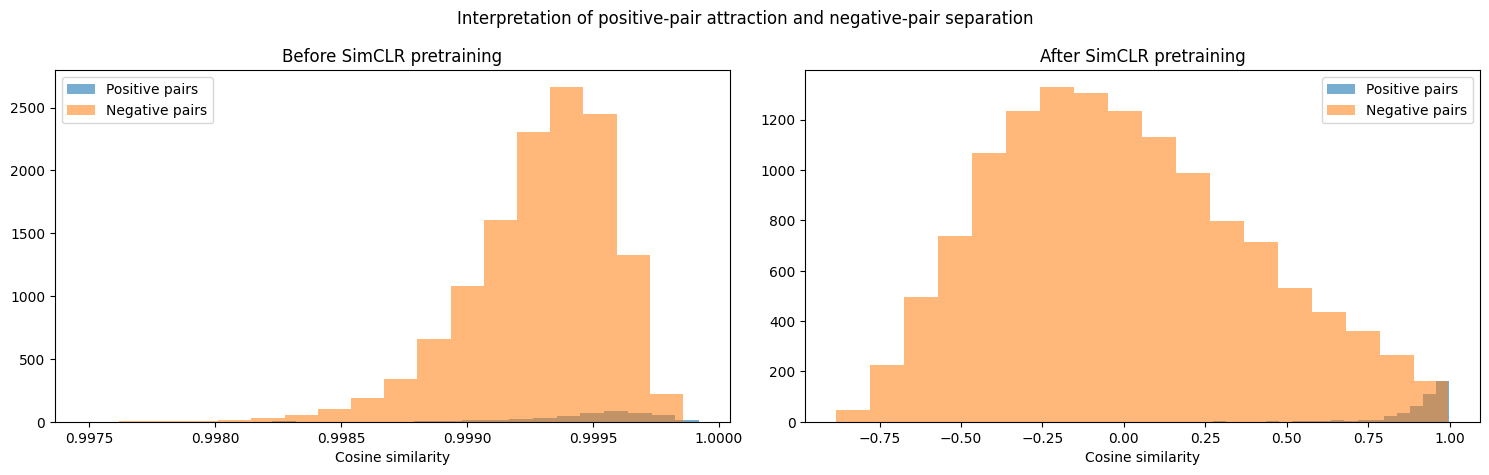

In [7]:
# ============================================================
# Cell 8: Contrastive-learning curves and pair-similarity distributions
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].plot(ssl_history["epoch"], ssl_history["train_loss"], marker="o", label="Training")
axes[0].plot(ssl_history["epoch"], ssl_history["valid_loss"], marker="o", label="Validation")
axes[0].set_title("NT-Xent loss during SimCLR pretraining")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(ssl_history["epoch"], ssl_history["valid_positive_similarity"], marker="o", label="Positive pairs")
axes[1].plot(ssl_history["epoch"], ssl_history["valid_negative_similarity"], marker="o", label="Negative pairs")
axes[1].set_title("Validation pair similarities")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cosine similarity")
axes[1].legend()
plt.tight_layout()
ssl_curve_path = OUTPUT_DIR / "simclr_training_curves.png"
plt.savefig(ssl_curve_path, dpi=220, bbox_inches="tight")
plt.show()


def collect_pair_similarities(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    """Collect matched-pair and unmatched-pair similarity samples for interpretation."""
    model.eval()
    positive_values, negative_values = [], []
    with torch.inference_mode():
        for first_view, second_view in loader:
            if first_view.size(0) < 2:
                continue
            first_view = move_images_to_device(first_view)
            second_view = move_images_to_device(second_view)
            with amp_context():
                _, first_projection = model(first_view)
                _, second_projection = model(second_view)
            first_projection = F.normalize(first_projection.float(), dim=1)
            second_projection = F.normalize(second_projection.float(), dim=1)
            similarity = first_projection @ second_projection.T
            positive_values.extend(similarity.diagonal().cpu().numpy().tolist())
            off_diagonal = ~torch.eye(similarity.size(0), dtype=torch.bool, device=similarity.device)
            negative_values.extend(similarity[off_diagonal].cpu().numpy().tolist())
    return np.asarray(positive_values), np.asarray(negative_values)


untrained_model = SimCLRModel().to(device)
untrained_model.load_state_dict(initial_simclr_state)
untrained_positive, untrained_negative = collect_pair_similarities(untrained_model, simclr_valid_loader)
trained_positive, trained_negative = collect_pair_similarities(simclr_model, simclr_valid_loader)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].hist(untrained_positive, bins=18, alpha=0.60, label="Positive pairs")
axes[0].hist(untrained_negative, bins=18, alpha=0.55, label="Negative pairs")
axes[0].set_title("Before SimCLR pretraining")
axes[0].set_xlabel("Cosine similarity")
axes[0].legend()
axes[1].hist(trained_positive, bins=18, alpha=0.60, label="Positive pairs")
axes[1].hist(trained_negative, bins=18, alpha=0.55, label="Negative pairs")
axes[1].set_title("After SimCLR pretraining")
axes[1].set_xlabel("Cosine similarity")
axes[1].legend()
plt.suptitle("Interpretation of positive-pair attraction and negative-pair separation")
plt.tight_layout()
similarity_path = OUTPUT_DIR / "simclr_similarity_distributions.png"
plt.savefig(similarity_path, dpi=220, bbox_inches="tight")
plt.show()

## 3. Stage B — Transfer the SimCLR encoder into DeepLabV3

DeepLabV3 uses atrous convolution and multi-scale contextual aggregation for pixel-level prediction. The ResNet-50 encoder learned in Stage A is transferred directly into the matching DeepLabV3 backbone; the SimCLR projection head is discarded because it is not part of the segmentation model.

The foreground-sensitive objective is:

\[
\mathcal{L}_{seg}=\mathcal{L}_{CE}+\mathcal{L}_{Dice}+0.4\mathcal{L}_{aux},
\]

where the auxiliary classification branch is included during training when returned by DeepLabV3.

In [8]:
# ============================================================
# Cell 9: Build DeepLabV3 and transfer the SimCLR-trained ResNet-50 encoder
# ============================================================
deeplab_model = deeplabv3_resnet50(
    weights=None,
    weights_backbone=None,
    num_classes=cfg.number_of_classes,
    aux_loss=True,
)

# Both modules use a ResNet-50 feature hierarchy. The SimCLR projection head does not transfer.
transfer_report = deeplab_model.backbone.load_state_dict(
    simclr_model.encoder.state_dict(), strict=False
)
print("Backbone weight transfer complete.")
print("Missing keys expected outside transferred feature blocks:", transfer_report.missing_keys)
print("Unexpected keys:", transfer_report.unexpected_keys)

deeplab_model = deeplab_model.to(device)

with torch.inference_mode():
    sample_images, sample_masks, _, _ = next(iter(segmentation_train_loader))
    with amp_context():
        sample_output = deeplab_model(move_images_to_device(sample_images[:2]))["out"]
assert tuple(sample_output.shape) == (2, cfg.number_of_classes, cfg.image_size, cfg.image_size)
print("DeepLabV3 output tensor shape:", tuple(sample_output.shape))

Backbone weight transfer complete.
Missing keys expected outside transferred feature blocks: []
Unexpected keys: []
DeepLabV3 output tensor shape: (2, 2, 224, 224)


In [9]:
# ============================================================
# Cell 10: Segmentation objective, metrics and 10-epoch fine-tuning
# ============================================================
def foreground_dice_loss(logits: torch.Tensor, targets: torch.Tensor, smoothing: float = 1.0) -> torch.Tensor:
    """Differentiable Dice loss applied to the tumour class probability."""
    foreground_probability = torch.softmax(logits, dim=1)[:, 1]
    foreground_target = (targets == 1).float()
    intersection = (foreground_probability * foreground_target).sum(dim=(1, 2))
    denominator = foreground_probability.sum(dim=(1, 2)) + foreground_target.sum(dim=(1, 2))
    dice = (2.0 * intersection + smoothing) / (denominator + smoothing)
    return 1.0 - dice.mean()


def segmentation_objective(outputs: dict[str, torch.Tensor], targets: torch.Tensor) -> torch.Tensor:
    """Calculate CE and Dice in float32 after an optional AMP model forward pass."""
    main_logits = outputs["out"].float()
    loss = F.cross_entropy(main_logits, targets) + foreground_dice_loss(main_logits, targets)
    if "aux" in outputs and outputs["aux"] is not None:
        auxiliary_logits = outputs["aux"].float()
        loss = loss + 0.4 * F.cross_entropy(auxiliary_logits, targets)
    return loss


def segmentation_scores(logits: torch.Tensor, targets: torch.Tensor) -> dict[str, float]:
    predictions = logits.argmax(dim=1)
    predicted_foreground = predictions == 1
    target_foreground = targets == 1
    intersection = (predicted_foreground & target_foreground).sum(dim=(1, 2)).float()
    union = (predicted_foreground | target_foreground).sum(dim=(1, 2)).float()
    sum_areas = predicted_foreground.sum(dim=(1, 2)).float() + target_foreground.sum(dim=(1, 2)).float()
    dice = ((2 * intersection + 1.0) / (sum_areas + 1.0)).mean().item()
    iou = ((intersection + 1.0) / (union + 1.0)).mean().item()
    pixel_accuracy = (predictions == targets).float().mean().item()
    return {"dice": dice, "iou": iou, "pixel_accuracy": pixel_accuracy}


def run_segmentation_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scaler: Optional[torch.amp.GradScaler] = None,
    description: str = "Segmentation",
) -> dict[str, float]:
    training = optimizer is not None
    model.train(training)
    records = defaultdict(list)

    for images, masks, _, _ in tqdm(loader, desc=description, leave=False):
        images = move_images_to_device(images)
        masks = masks.to(device, non_blocking=(device.type == "cuda")).long().contiguous()
        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with amp_context():
                outputs = model(images)
            loss = segmentation_objective(outputs, masks)
            scores = segmentation_scores(outputs["out"].float().detach(), masks)
            if training:
                if AMP_ENABLED:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        records["loss"].append(loss.item())
        for metric_name, metric_value in scores.items():
            records[metric_name].append(metric_value)

    return {metric_name: float(np.mean(values)) for metric_name, values in records.items()}


seg_optimizer = torch.optim.AdamW(
    deeplab_model.parameters(), lr=cfg.seg_learning_rate, weight_decay=cfg.weight_decay
)
seg_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(seg_optimizer, T_max=cfg.seg_epochs)
seg_records = []
best_validation_dice = -1.0
best_deeplab_state = None

for epoch in tqdm(range(1, cfg.seg_epochs + 1), desc="Stage B: DeepLabV3 epochs"):
    training_results = run_segmentation_epoch(
        deeplab_model, segmentation_train_loader, seg_optimizer, SCALER,
        description=f"DeepLabV3 train {epoch}/{cfg.seg_epochs}"
    )
    with torch.inference_mode():
        validation_results = run_segmentation_epoch(
            deeplab_model, segmentation_valid_loader,
            description=f"DeepLabV3 valid {epoch}/{cfg.seg_epochs}"
        )
    seg_scheduler.step()

    seg_records.append(
        {
            "epoch": epoch,
            **{f"train_{key}": value for key, value in training_results.items()},
            **{f"valid_{key}": value for key, value in validation_results.items()},
            "learning_rate": seg_optimizer.param_groups[0]["lr"],
        }
    )
    if validation_results["dice"] > best_validation_dice:
        best_validation_dice = validation_results["dice"]
        best_deeplab_state = copy.deepcopy({key: value.detach().cpu() for key, value in deeplab_model.state_dict().items()})

deeplab_model.load_state_dict(best_deeplab_state)
deeplab_model.to(device)
seg_history = pd.DataFrame(seg_records)
seg_checkpoint = OUTPUT_DIR / "simclr_initialized_deeplabv3_binary_segmentation_amp_stable.pt"
seg_history_file = OUTPUT_DIR / "deeplabv3_training_history.csv"
torch.save(deeplab_model.state_dict(), seg_checkpoint)
seg_history.to_csv(seg_history_file, index=False)

print(f"Best validation Dice coefficient: {best_validation_dice:.4f}")
display(seg_history.round(4))
print("Saved:", seg_checkpoint)

Stage B: DeepLabV3 epochs:   0%|          | 0/10 [00:00<?, ?it/s]

DeepLabV3 train 1/10:   0%|          | 0/188 [00:00<?, ?it/s]

DeepLabV3 valid 1/10:   0%|          | 0/54 [00:00<?, ?it/s]

DeepLabV3 train 2/10:   0%|          | 0/188 [00:00<?, ?it/s]

DeepLabV3 valid 2/10:   0%|          | 0/54 [00:00<?, ?it/s]

...

DeepLabV3 train 10/10:   0%|          | 0/188 [00:00<?, ?it/s]

DeepLabV3 valid 10/10:   0%|          | 0/54 [00:00<?, ?it/s]

Best validation Dice coefficient: 0.6996


,epoch,train_loss,train_dice,train_iou,train_pixel_accuracy,valid_loss,valid_dice,valid_iou,valid_pixel_accuracy,learning_rate
0,1,1.1247,0.4208,0.2959,0.8932,0.8951,0.5099,0.3755,0.9459,0.0001
1,2,0.6593,0.5944,0.4579,0.9689,0.6730,0.5918,0.4563,0.9575,0.0001
2,3,0.5125,0.6585,0.5257,0.9745,0.5504,0.6262,0.4976,0.9710,0.0001
3,4,0.4340,0.7040,0.5762,0.9784,0.6319,0.6433,0.5168,0.9657,0.0001
4,5,0.3696,0.7460,0.6228,0.9814,0.5263,0.6614,0.5363,0.9685,0.0000
5,6,0.3123,0.7864,0.6699,0.9846,0.4290,0.6952,0.5759,0.9780,0.0000
6,7,0.2718,0.8145,0.7057,0.9867,0.4968,0.6873,0.5713,0.9749,0.0000
7,8,0.2359,0.8402,0.7401,0.9886,0.4547,0.6972,0.5815,0.9774,0.0000
8,9,0.2088,0.8598,0.7668,0.9901,0.4539,0.6928,0.5788,0.9775,0.0000
9,10,0.1946,0.8707,0.7822,0.9909,0.4275,0.6996,0.5868,0.9794,0.0000


Saved: /kaggle/working/simclr_deeplabv3_outputs/simclr_initialized_deeplabv3_binary_segmentation_amp_stable.pt


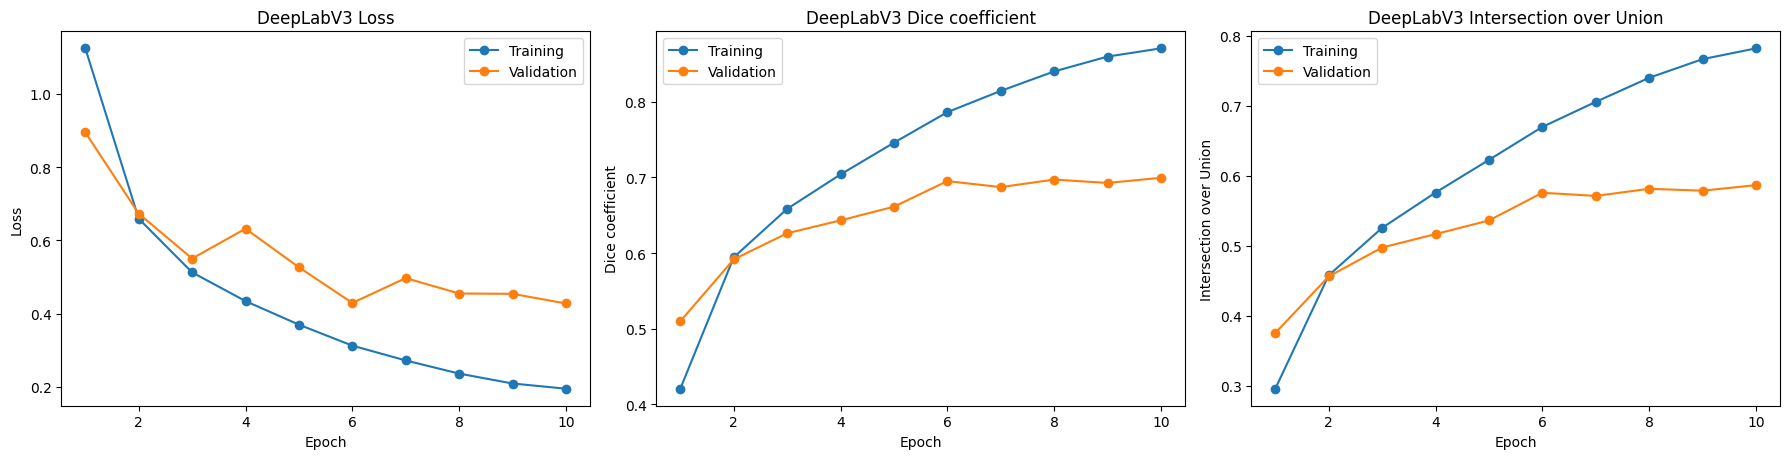

DeepLabV3 test evaluation:   0%|          | 0/27 [00:00<?, ?it/s]

Held-out test-set metrics


,loss,dice,iou,pixel_accuracy
0,0.4339,0.6952,0.579,0.9794


Saved: /kaggle/working/simclr_deeplabv3_outputs/deeplabv3_test_metrics.csv


In [10]:
# ============================================================
# Cell 11: Training curves and held-out test metrics
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.7))
for axis, metric, label in zip(
    axes, ["loss", "dice", "iou"], ["Loss", "Dice coefficient", "Intersection over Union"]
):
    axis.plot(seg_history["epoch"], seg_history[f"train_{metric}"], marker="o", label="Training")
    axis.plot(seg_history["epoch"], seg_history[f"valid_{metric}"], marker="o", label="Validation")
    axis.set_title(f"DeepLabV3 {label}")
    axis.set_xlabel("Epoch")
    axis.set_ylabel(label)
    axis.legend()
plt.tight_layout()
seg_curve_path = OUTPUT_DIR / "deeplabv3_training_curves.png"
plt.savefig(seg_curve_path, dpi=220, bbox_inches="tight")
plt.show()

with torch.inference_mode():
    test_results = run_segmentation_epoch(
        deeplab_model, segmentation_test_loader, description="DeepLabV3 test evaluation"
    )
test_metrics = pd.DataFrame([test_results])
test_metrics_path = OUTPUT_DIR / "deeplabv3_test_metrics.csv"
test_metrics.to_csv(test_metrics_path, index=False)
print("Held-out test-set metrics")
display(test_metrics.round(4))
print("Saved:", test_metrics_path)

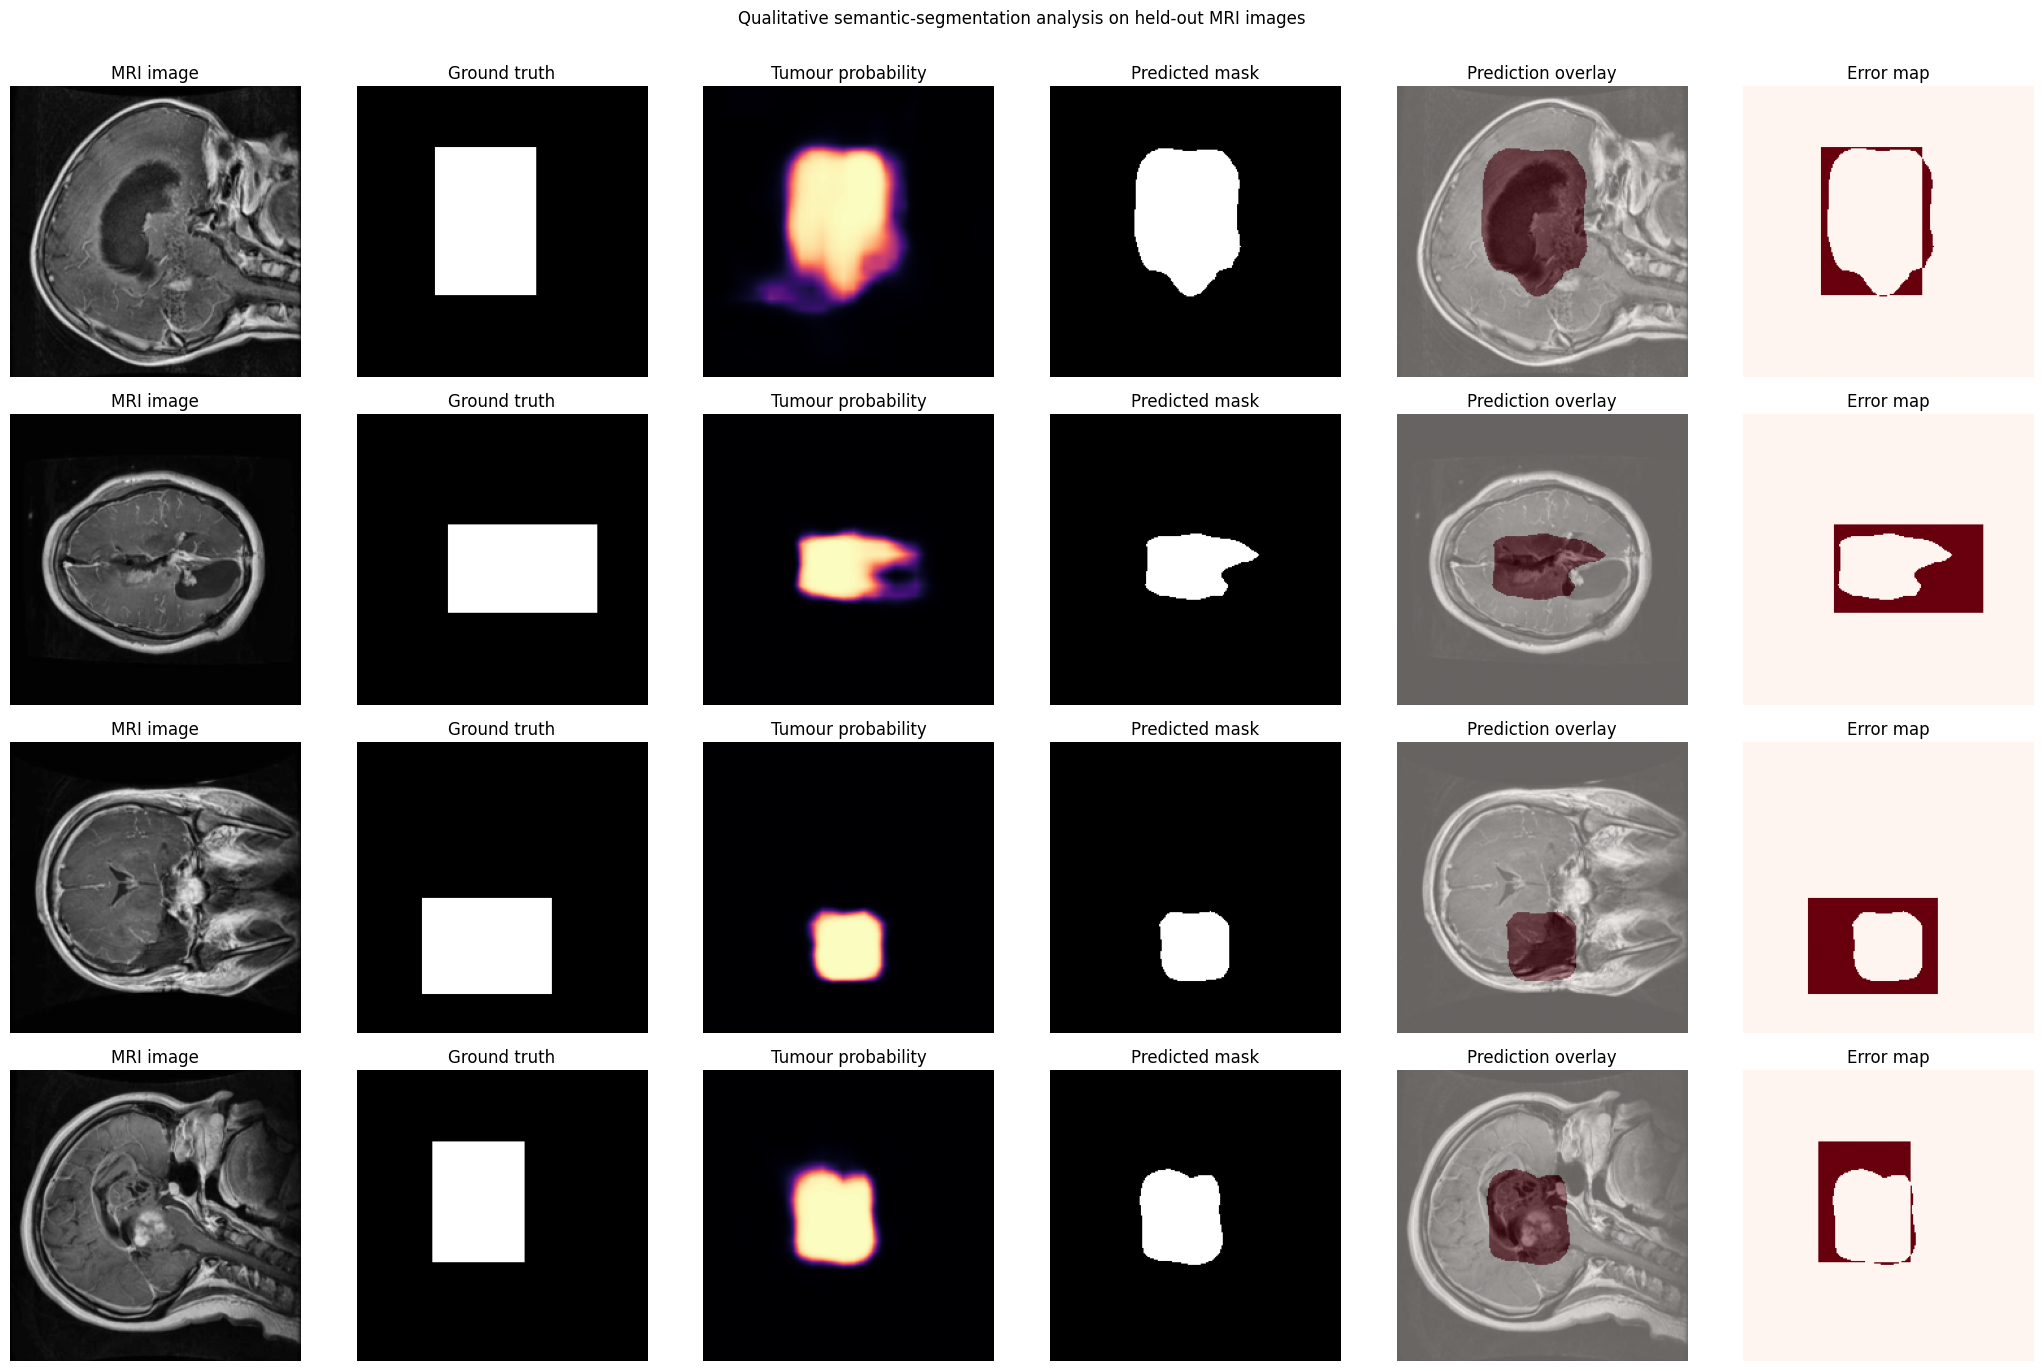

Saved: /kaggle/working/simclr_deeplabv3_outputs/qualitative_segmentation_predictions.png


In [11]:
# ============================================================
# Cell 12: Qualitative predictions — image, mask, probability, prediction, overlay and error
# ============================================================
def predict_one_sample(dataset: Dataset, index: int):
    image_tensor, target_mask, _, image_path = dataset[index]
    batch = move_images_to_device(image_tensor.unsqueeze(0))
    deeplab_model.eval()
    with torch.inference_mode():
        with amp_context():
            output = deeplab_model(batch)["out"]
        probability = torch.softmax(output.float(), dim=1)[0, 1].cpu()
    predicted_mask = (probability >= 0.5).long()
    error_map = (predicted_mask != target_mask).long()
    return image_tensor, target_mask, probability, predicted_mask, error_map, image_path


# Select cases with relatively prominent tumour masks for visible interpretation.
qualitative_indices = (
    split_frames["test"].sort_values("mask_ratio", ascending=False)
    .head(cfg.number_of_qualitative_samples).index.tolist()
)
fig, axes = plt.subplots(len(qualitative_indices), 6, figsize=(21, 3.4 * len(qualitative_indices)))
if len(qualitative_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_number, sample_index in enumerate(qualitative_indices):
    image_tensor, target_mask, probability, predicted_mask, error_map, image_path = predict_one_sample(
        segmentation_test_dataset, sample_index
    )
    display_image = denormalise_image(image_tensor).permute(1, 2, 0)
    panels = [display_image, target_mask, probability, predicted_mask, display_image, error_map]
    titles = ["MRI image", "Ground truth", "Tumour probability", "Predicted mask", "Prediction overlay", "Error map"]
    for column, (panel, title) in enumerate(zip(panels, titles)):
        axes[row_number, column].imshow(panel, cmap=None if column in [0, 4] else ("magma" if column == 2 else "gray"))
        if column == 4:
            axes[row_number, column].imshow(predicted_mask, cmap="Reds", alpha=0.40, vmin=0, vmax=1)
        if column == 5:
            axes[row_number, column].imshow(error_map, cmap="Reds", vmin=0, vmax=1)
        axes[row_number, column].set_title(title)
        axes[row_number, column].axis("off")

plt.suptitle("Qualitative semantic-segmentation analysis on held-out MRI images", y=1.005)
plt.tight_layout()
qualitative_path = OUTPUT_DIR / "qualitative_segmentation_predictions.png"
plt.savefig(qualitative_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", qualitative_path)

## 4. t-SNE feature-space interpretation

The same held-out images are encoded at three learning points:

1. **Before SimCLR:** a randomly initialised ResNet-50 encoder;
2. **After SimCLR:** the encoder after contrastive representation learning;
3. **After segmentation fine-tuning:** the DeepLabV3 backbone after using pixel-level tumour masks.

The colouring uses tumour-area groups only to interpret the visual arrangement; it is not supplied to SimCLR during training. t-SNE is a qualitative projection and must not be treated as a performance metric.

Extracting Before SimCLR features:   0%|          | 0/27 [00:00<?, ?it/s]

Extracting After SimCLR features:   0%|          | 0/27 [00:00<?, ?it/s]

Extracting After DeepLabV3 fine-tuning features:   0%|          | 0/27 [00:00<?, ?it/s]

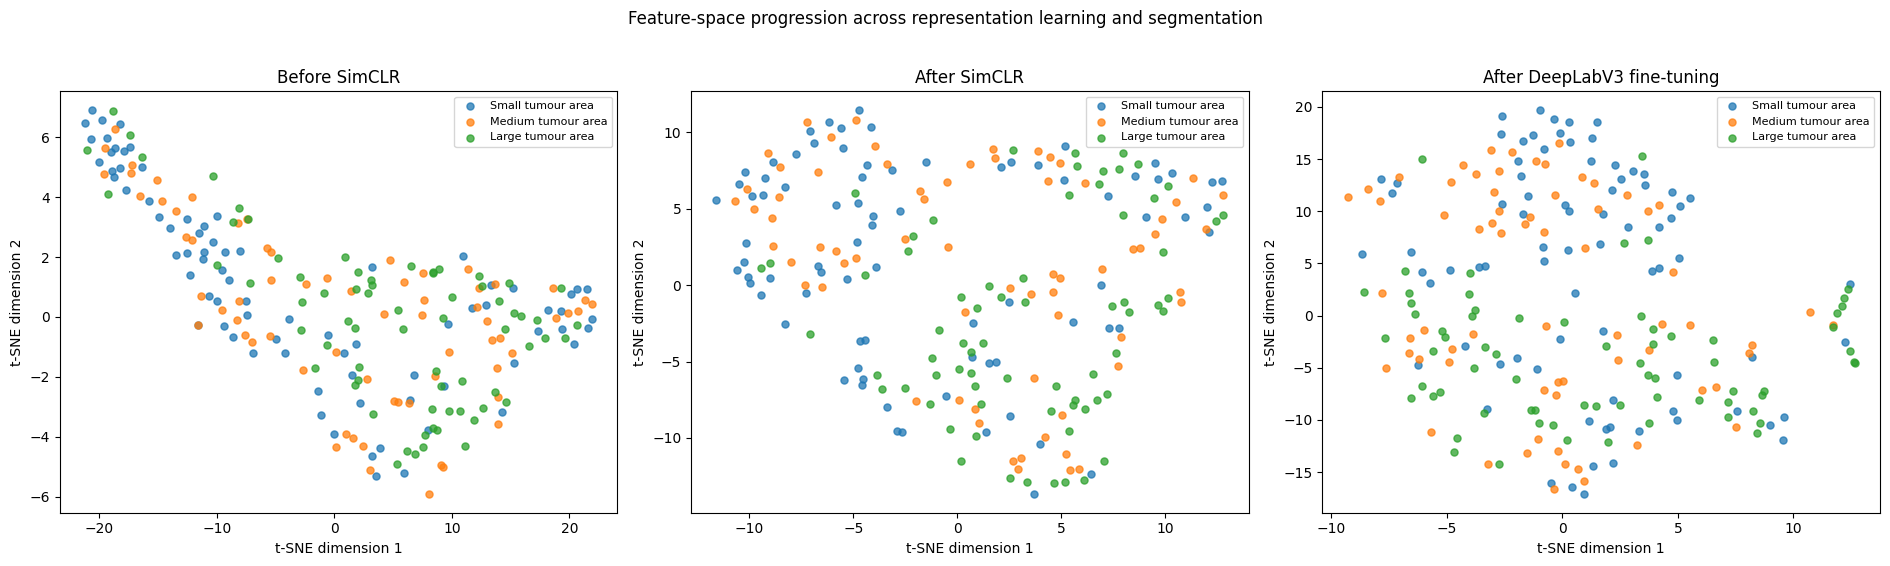

Saved: /kaggle/working/simclr_deeplabv3_outputs/feature_space_progression_tsne.png


In [12]:
# ============================================================
# Cell 13: t-SNE comparison before SSL, after SSL and after segmentation fine-tuning
# ============================================================
feature_frame = split_frames["test"].copy()
if len(feature_frame) > cfg.tsne_max_samples:
    feature_frame = feature_frame.sample(cfg.tsne_max_samples, random_state=cfg.seed).reset_index(drop=True)
feature_loader = DataLoader(
    FeatureDataset(feature_frame), batch_size=cfg.seg_batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=(device.type == "cuda")
)

initial_model = SimCLRModel().to(device)
initial_model.load_state_dict(initial_simclr_state)
initial_model.eval()
simclr_model.eval()
deeplab_model.eval()


def collect_encoder_features(stage: str) -> tuple[np.ndarray, np.ndarray]:
    feature_values, group_values = [], []
    with torch.inference_mode():
        for images, groups in tqdm(feature_loader, desc=f"Extracting {stage} features", leave=False):
            images = move_images_to_device(images)
            with amp_context():
                if stage == "Before SimCLR":
                    features, _ = initial_model(images)
                elif stage == "After SimCLR":
                    features, _ = simclr_model(images)
                elif stage == "After DeepLabV3 fine-tuning":
                    backbone_output = deeplab_model.backbone(images)["out"]
                    features = F.adaptive_avg_pool2d(backbone_output, output_size=(1, 1)).flatten(1)
                else:
                    raise ValueError(f"Unknown feature stage: {stage}")
            feature_values.append(features.float().cpu().numpy())
            group_values.append(groups.numpy())
    return np.concatenate(feature_values), np.concatenate(group_values)


def project_tsne(features: np.ndarray) -> np.ndarray:
    sample_count = features.shape[0]
    perplexity = min(30, max(5, (sample_count - 1) // 3))
    return TSNE(
        n_components=2, perplexity=perplexity, init="pca",
        learning_rate="auto", random_state=cfg.seed
    ).fit_transform(features)


stages = ["Before SimCLR", "After SimCLR", "After DeepLabV3 fine-tuning"]
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for axis, stage in zip(axes, stages):
    features, group_labels = collect_encoder_features(stage)
    coordinates = project_tsne(features)
    for group_identifier in np.unique(group_labels):
        selected = group_labels == group_identifier
        axis.scatter(
            coordinates[selected, 0], coordinates[selected, 1], s=26, alpha=0.75,
            label=feature_group_names.get(int(group_identifier), str(group_identifier))
        )
    axis.set_title(stage)
    axis.set_xlabel("t-SNE dimension 1")
    axis.set_ylabel("t-SNE dimension 2")
    axis.legend(fontsize=8)
plt.suptitle("Feature-space progression across representation learning and segmentation", y=1.02)
plt.tight_layout()
tsne_path = OUTPUT_DIR / "feature_space_progression_tsne.png"
plt.savefig(tsne_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", tsne_path)

In [13]:
# ============================================================
# Cell 14: Output summary for retrieval from the Kaggle working directory
# ============================================================
produced_files = sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file())
print("Experiment completed. Files written to:", OUTPUT_DIR)
for file_name in produced_files:
    print(" -", file_name)

Experiment completed. Files written to: /kaggle/working/simclr_deeplabv3_outputs
 - deeplabv3_test_metrics.csv
 - deeplabv3_training_curves.png
 - deeplabv3_training_history.csv
 - feature_space_progression_tsne.png
 - qualitative_segmentation_predictions.png
 - simclr_initialized_deeplabv3_binary_segmentation_amp_stable.pt
 - simclr_resnet50_encoder_projection_head_amp_stable.pt
 - simclr_similarity_distributions.png
 - simclr_training_curves.png
 - simclr_training_history.csv


## 5. Classroom interpretation guide

After running the notebook, students should discuss the following observations:

1. **Polygon conversion:** Examine whether the foreground masks correctly follow tumour boundaries and whether multiple polygons merge into one binary semantic map.
2. **Augmentation validity:** Verify that two SimCLR views alter appearance and crop position without destroying clinically meaningful structure.
3. **Contrastive behaviour:** Compare positive- and negative-pair similarity distributions before and after pretraining. A useful representation should increase relative similarity of paired views.
4. **Segmentation behaviour:** Interpret validation Dice and IoU alongside the probability map and error map. Boundary uncertainty may remain visible even when pixel accuracy is high.
5. **Feature-space change:** Describe changes in t-SNE organisation from random initialisation to SSL representation learning and then mask-supervised fine-tuning. The plot is explanatory rather than inferential.
6. **Study limitation:** The ten-epoch run is designed to teach a reproducible pipeline; it must not be interpreted as a clinically validated tumour segmentation model.

### Files generated during execution

```text
/kaggle/working/simclr_deeplabv3_outputs/
├── simclr_resnet50_encoder_projection_head_amp_stable.pt
├── simclr_training_history.csv
├── simclr_training_curves.png
├── simclr_similarity_distributions.png
├── simclr_initialized_deeplabv3_binary_segmentation_amp_stable.pt
├── deeplabv3_training_history.csv
├── deeplabv3_training_curves.png
├── deeplabv3_test_metrics.csv
├── qualitative_segmentation_predictions.png
└── feature_space_progression_tsne.png
```

### Method references

- Chen, T., Kornblith, S., Norouzi, M., and Hinton, G. (2020). *A Simple Framework for Contrastive Learning of Visual Representations*. Proceedings of ICML.
- Chen, L.-C., Papandreou, G., Schroff, F., and Adam, H. (2017). *Rethinking Atrous Convolution for Semantic Image Segmentation*.
- PyTorch documentation for automatic mixed precision and TorchVision DeepLabV3 implementations.

---
**Prepared for CSE 438 · Digital Image Processing**  
**Course Instructor:** Dr Md Rifat Ahmmad Rashid  
**Dept of CSE, East West University (EWU)**